In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("/content/drive/MyDrive/PROJECT/healthcare_dataset.csv")

In [7]:
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [5]:
df.tail()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
55495,eLIZABeTH jaCkSOn,42,Female,O+,Asthma,2020-08-16,Joshua Jarvis,Jones-Thompson,Blue Cross,2650.714952,417,Elective,2020-09-15,Penicillin,Abnormal
55496,KYle pEREz,61,Female,AB-,Obesity,2020-01-23,Taylor Sullivan,Tucker-Moyer,Cigna,31457.797307,316,Elective,2020-02-01,Aspirin,Normal
55497,HEATher WaNG,38,Female,B+,Hypertension,2020-07-13,Joe Jacobs DVM,"and Mahoney Johnson Vasquez,",UnitedHealthcare,27620.764717,347,Urgent,2020-08-10,Ibuprofen,Abnormal
55498,JENniFER JOneS,43,Male,O-,Arthritis,2019-05-25,Kimberly Curry,"Jackson Todd and Castro,",Medicare,32451.092358,321,Elective,2019-05-31,Ibuprofen,Abnormal
55499,jAMES GARCiA,53,Female,O+,Arthritis,2024-04-02,Dennis Warren,Henry Sons and,Aetna,4010.134172,448,Urgent,2024-04-29,Ibuprofen,Abnormal


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  object 
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  object 
 3   Blood Type          55500 non-null  object 
 4   Medical Condition   55500 non-null  object 
 5   Date of Admission   55500 non-null  object 
 6   Doctor              55500 non-null  object 
 7   Hospital            55500 non-null  object 
 8   Insurance Provider  55500 non-null  object 
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  object 
 12  Discharge Date      55500 non-null  object 
 13  Medication          55500 non-null  object 
 14  Test Results        55500 non-null  object 
dtypes: float64(1), int64(2), object(12)
memory usage: 6.4

In [8]:
df.isnull()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55495,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
55496,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
55497,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
55498,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [9]:
cat_cols = [
    'Gender',
    'Blood Type',
    'Medical Condition',
    'Admission Type',
    'Medication',
    'Test Results'
]

for col in cat_cols:
    df[col] = df[col].astype(str).str.strip().str.title()

print(df[cat_cols].head())

   Gender Blood Type Medical Condition Admission Type   Medication  \
0    Male         B-            Cancer         Urgent  Paracetamol   
1    Male         A+           Obesity      Emergency    Ibuprofen   
2  Female         A-           Obesity      Emergency      Aspirin   
3  Female         O+          Diabetes       Elective    Ibuprofen   
4  Female        Ab+            Cancer         Urgent   Penicillin   

   Test Results  
0        Normal  
1  Inconclusive  
2        Normal  
3      Abnormal  
4      Abnormal  


In [10]:
df['Date of Admission'] = pd.to_datetime(
    df['Date of Admission']
)

df['Discharge Date'] = pd.to_datetime(
    df['Discharge Date']
)

print(df[['Date of Admission', 'Discharge Date']].head())

  Date of Admission Discharge Date
0        2024-01-31     2024-02-02
1        2019-08-20     2019-08-26
2        2022-09-22     2022-10-07
3        2020-11-18     2020-12-18
4        2022-09-19     2022-10-09


In [11]:
df['Stay Days'] = (
    df['Discharge Date'] -
    df['Date of Admission']
).dt.days

print(df[['Date of Admission',
          'Discharge Date',
          'Stay Days']].head())

  Date of Admission Discharge Date  Stay Days
0        2024-01-31     2024-02-02          2
1        2019-08-20     2019-08-26          6
2        2022-09-22     2022-10-07         15
3        2020-11-18     2020-12-18         30
4        2022-09-19     2022-10-09         20


In [12]:
demographics = pd.crosstab(
    df['Medical Condition'],
    df['Gender']
)

print(demographics)

Gender             Female  Male
Medical Condition              
Arthritis            4686  4622
Asthma               4553  4632
Cancer               4602  4625
Diabetes             4651  4653
Hypertension         4612  4633
Obesity              4622  4609


In [13]:
admission_counts = df['Admission Type'].value_counts()
print(admission_counts)

Admission Type
Elective     18655
Urgent       18576
Emergency    18269
Name: count, dtype: int64


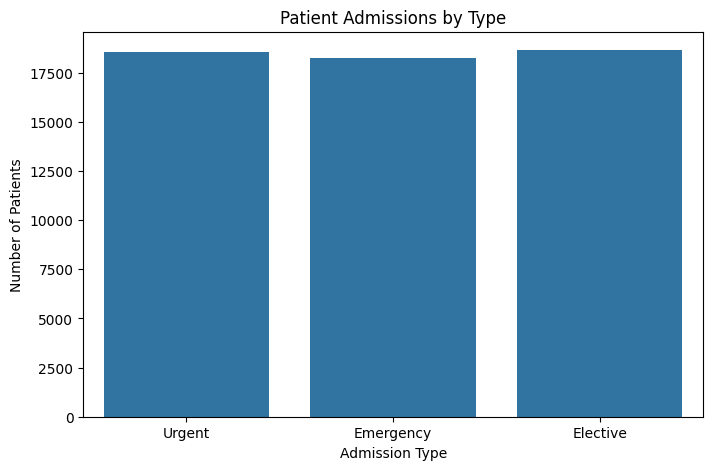

In [14]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='Admission Type'
)

plt.title('Patient Admissions by Type')
plt.xlabel('Admission Type')
plt.ylabel('Number of Patients')
plt.show()

In [15]:
print(df['Billing Amount'].describe())

count    55500.000000
mean     25539.316097
std      14211.454431
min      -2008.492140
25%      13241.224652
50%      25538.069376
75%      37820.508436
max      52764.276736
Name: Billing Amount, dtype: float64


In [16]:
print("Mean:", df['Billing Amount'].mean())
print("Median:", df['Billing Amount'].median())
print("Standard Deviation:", df['Billing Amount'].std())
print("Minimum:", df['Billing Amount'].min())
print("Maximum:", df['Billing Amount'].max())

Mean: 25539.316097211795
Median: 25538.069375965664
Standard Deviation: 14211.45443086446
Minimum: -2008.4921398591305
Maximum: 52764.276736469175


In [17]:
print(df['Stay Days'].describe())

count    55500.000000
mean        15.509009
std          8.659600
min          1.000000
25%          8.000000
50%         15.000000
75%         23.000000
max         30.000000
Name: Stay Days, dtype: float64


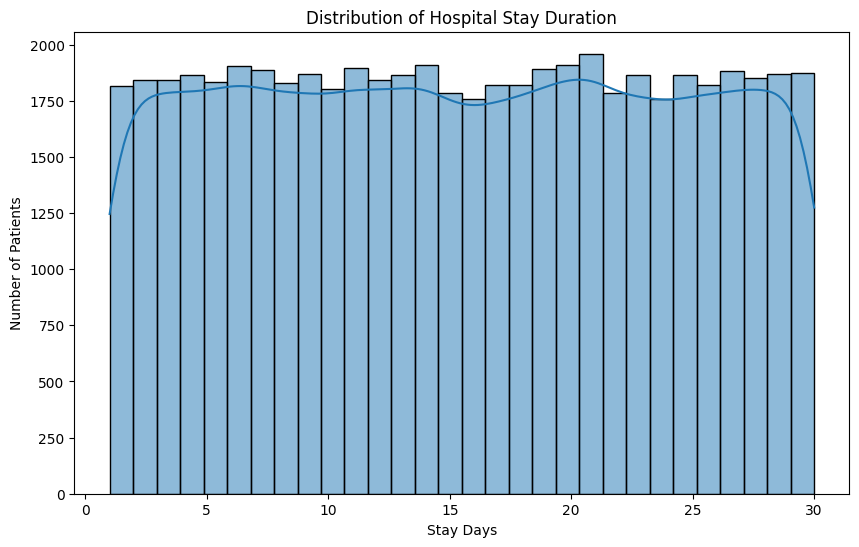

In [18]:
plt.figure(figsize=(10,6))

sns.histplot(
    df['Stay Days'],
    bins=30,
    kde=True
)

plt.title('Distribution of Hospital Stay Duration')
plt.xlabel('Stay Days')
plt.ylabel('Number of Patients')
plt.show()

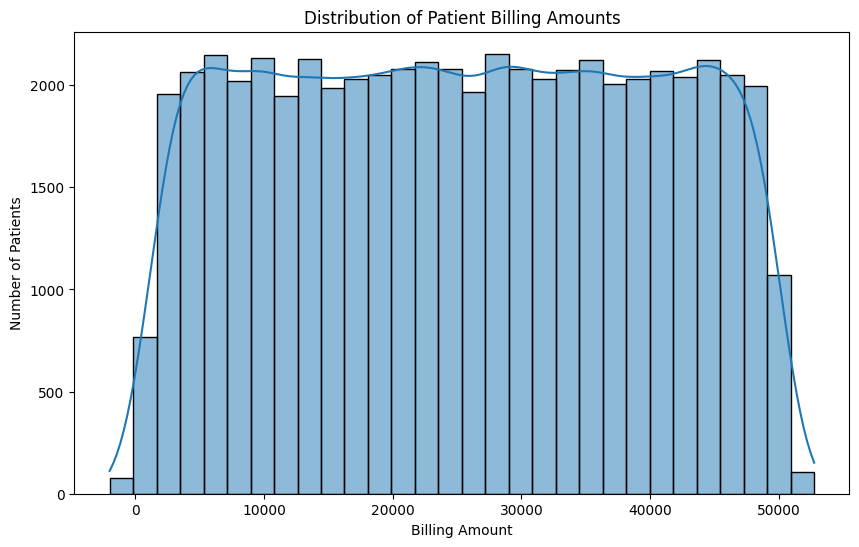

In [19]:
plt.figure(figsize=(10,6))

sns.histplot(
    df['Billing Amount'],
    bins=30,
    kde=True
)

plt.title('Distribution of Patient Billing Amounts')
plt.xlabel('Billing Amount')
plt.ylabel('Number of Patients')
plt.show()